In [1]:

# Basic libraries
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

In [3]:
# Load Netflix dataset
df = pd.read_csv("C:/Users/Shivani/Downloads/Netflix Dataset 1.csv")
     

In [4]:

# Display first few rows
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [5]:

# Check dataset information
df.info()
     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [6]:


# Check for missing values
df.isnull().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

In [7]:
# Basic statistics
df.describe(include='all')

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s684,Movie,Backfire,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


In [8]:

# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [9]:


# Fill missing values
df['Country']=df['Country'].fillna('Unknown')
df['Director']=df['Director'].fillna('Unknown')
df['Cast']=df['Cast'].fillna('Not Available')

In [10]:
df['Release_Date'] = df['Release_Date'].astype(str).str.strip()

In [11]:
# Convert 'Release_Date' to datetime format
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce', format='mixed')

In [12]:
# Extract year from 'Release_Date'
df['year_added'] = df['Release_Date'].dt.year
     

In [13]:
df[['Release_Date', 'year_added']].head(10)

,Release_Date,year_added
0,2020-08-14,2020.0
1,2016-12-23,2016.0
2,2018-12-20,2018.0
3,2017-11-16,2017.0
4,2020-01-01,2020.0
5,2017-07-01,2017.0
6,2020-06-01,2020.0
7,2019-11-01,2019.0
8,2019-04-01,2019.0
9,2017-12-15,2017.0


In [14]:
df['year_added'].isnull().sum()
     

np.int64(10)

In [15]:

# Keep all rows (fill missing years)
df['year_added'].fillna(0, inplace=True)

C:\Users\Shivani\AppData\Local\Temp\ipykernel_9448\747604989.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['year_added'].fillna(0, inplace=True)


In [16]:


df.info()
     

<class 'pandas.core.frame.DataFrame'>
Index: 7787 entries, 0 to 7788
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_Id       7787 non-null   object        
 1   Category      7787 non-null   object        
 2   Title         7787 non-null   object        
 3   Director      7787 non-null   object        
 4   Cast          7787 non-null   object        
 5   Country       7787 non-null   object        
 6   Release_Date  7777 non-null   datetime64[ns]
 7   Rating        7780 non-null   object        
 8   Duration      7787 non-null   object        
 9   Type          7787 non-null   object        
 10  Description   7787 non-null   object        
 11  year_added    7787 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(10)
memory usage: 790.9+ KB


In [17]:
# Handle Duration column — split numeric + unit
df['Duration_num'] = df['Duration'].str.extract('(\d+)').astype(float)

In [18]:

df['Duration_type'] = df['Duration'].str.extract('([a-zA-Z]+)')

In [19]:
# Convert Category to categorical type
df['Category'] = df['Category'].astype('category')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7787 entries, 0 to 7788
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Show_Id        7787 non-null   object        
 1   Category       7787 non-null   category      
 2   Title          7787 non-null   object        
 3   Director       7787 non-null   object        
 4   Cast           7787 non-null   object        
 5   Country        7787 non-null   object        
 6   Release_Date   7777 non-null   datetime64[ns]
 7   Rating         7780 non-null   object        
 8   Duration       7787 non-null   object        
 9   Type           7787 non-null   object        
 10  Description    7787 non-null   object        
 11  year_added     7787 non-null   float64       
 12  Duration_num   7787 non-null   float64       
 13  Duration_type  7787 non-null   object        
dtypes: category(1), datetime64[ns](1), float64(2), object(10)
memory usage: 859.4

In [21]:
# create exploded dataframe for genre-level analysis
df['genres'] = df['Type'].str.split(', ')
genre_df = df.explode('genres').reset_index(drop=True)
genre_df['genres'] = genre_df['genres'].str.strip()
genre_df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description,year_added,Duration_num,Duration_type,genres
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,4.0,Seasons,International TV Shows
1,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,4.0,Seasons,TV Dramas
2,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,4.0,Seasons,TV Sci-Fi & Fantasy
3,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,93.0,min,Dramas
4,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,93.0,min,International Movies


In [22]:
# Remove duplicates if any
print('before dup:', df.shape)
     

before dup: (7787, 15)


In [23]:
df.drop_duplicates(subset=['Show_Id','Title'], inplace=True)   # tweak subset if needed
print('after dup:', df.shape)

after dup: (7787, 15)


In [24]:
df.duplicated(subset=['Show_Id','Title']).sum()

np.int64(0)

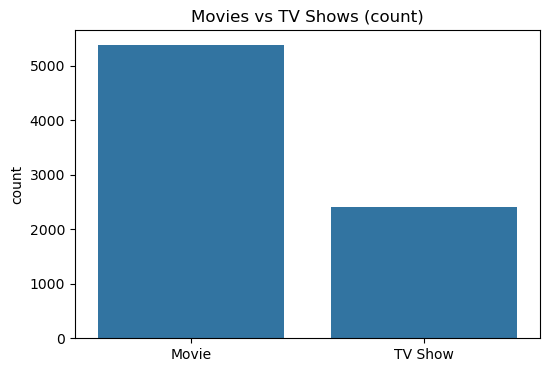

In [25]:
# Overall count (bar)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index)
plt.title('Movies vs TV Shows (count)')
plt.xlabel('')
plt.show()

C:\Users\Shivani\AppData\Local\Temp\ipykernel_9448\1771530621.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df[df['year_added'].notna() & (df['year_added']!=0)].groupby(['year_added','Category']).size().reset_index(name='count')


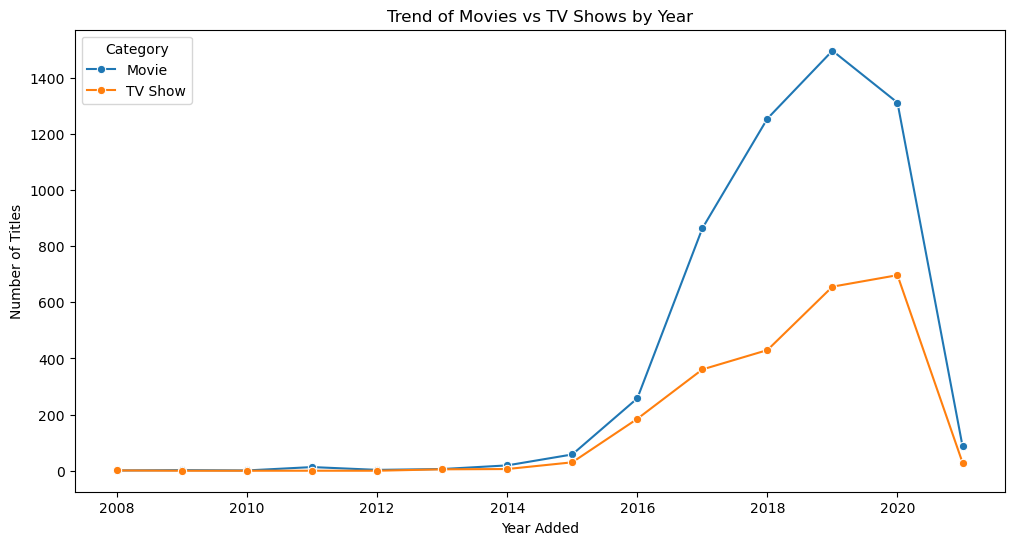

In [26]:
# Trend over years (drop unknown year == 0 or NaN)
trend = df[df['year_added'].notna() & (df['year_added']!=0)].groupby(['year_added','Category']).size().reset_index(name='count')
plt.figure(figsize=(12,6))
sns.lineplot(data=trend, x='year_added', y='count', hue='Category', marker='o')
plt.title('Trend of Movies vs TV Shows by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

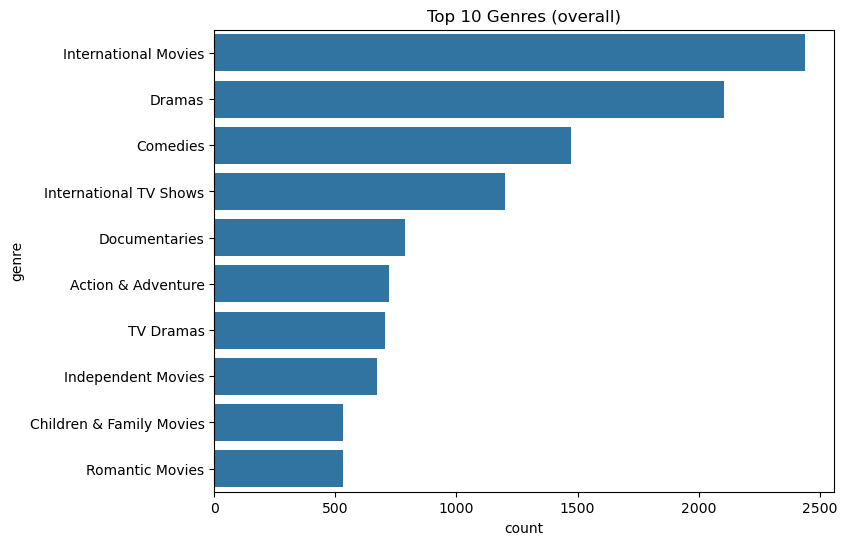

In [27]:

# Top 10 genres overall
top_genres = genre_df['genres'].value_counts().head(10).reset_index()
top_genres.columns = ['genre','count']
plt.figure(figsize=(8,6))
sns.barplot(data=top_genres, x='count', y='genre')
plt.title('Top 10 Genres (overall)')
plt.show()

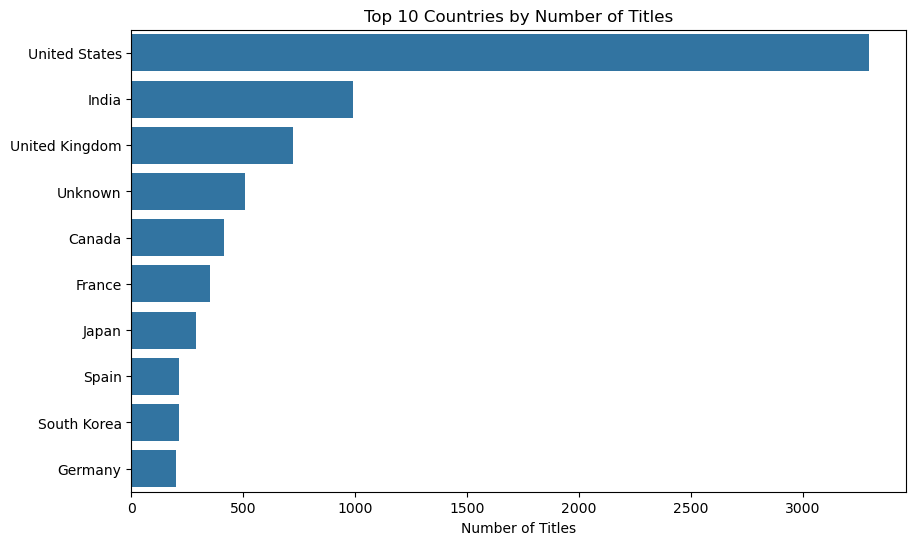

In [28]:

# handle multiple countries per row (if present)
country_df = df.assign(country=df['Country'].str.split(', ')).explode('country')
top_countries = country_df['country'].value_counts().head(10).reset_index()
top_countries.columns = ['country','count']

plt.figure(figsize=(10,6))
sns.barplot(data=top_countries, x='count', y='country')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.show()

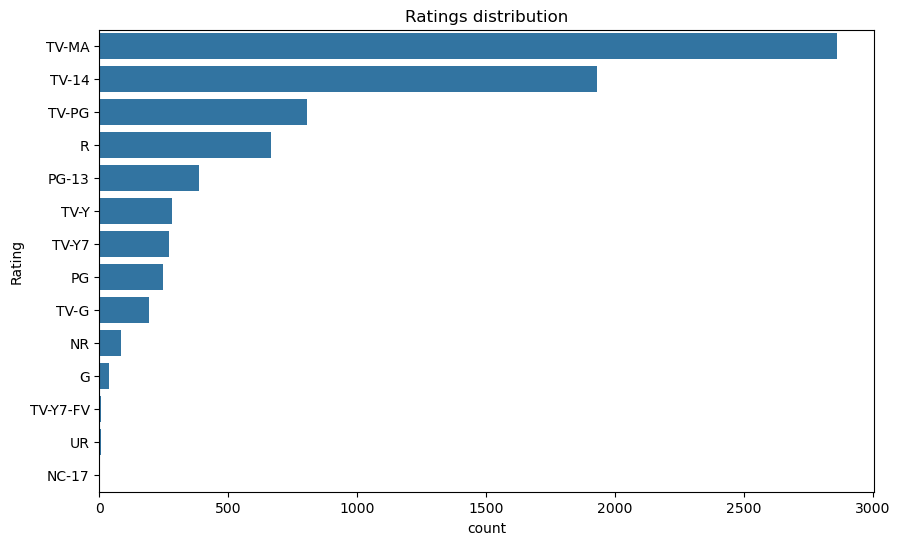

In [29]:

plt.figure(figsize=(10,6))
sns.countplot(y='Rating', data=df, order=df['Rating'].value_counts().index)
plt.title('Ratings distribution')
plt.show()

Avg movie length (min): 99.3
Avg seasons for shows: nan


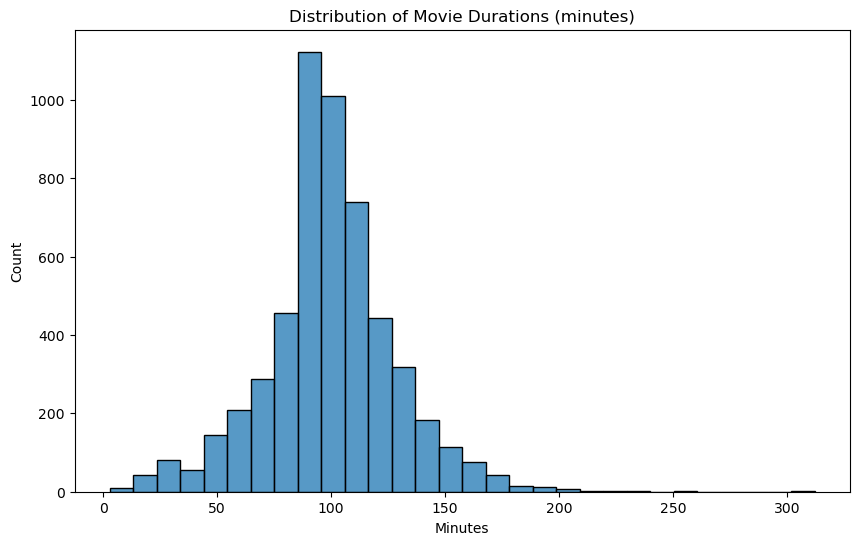

In [30]:
# Average movie minutes
avg_min = df[df['Duration_type']=='min']['Duration_num'].mean()
avg_seasons = df[df['Duration_type']=='season']['Duration_num'].mean()
print('Avg movie length (min):', round(avg_min,1))
print('Avg seasons for shows:', round(avg_seasons,1))

# Histogram for movie lengths
plt.figure(figsize=(10,6))
sns.histplot(df[df['Duration_type']=='min']['Duration_num'].dropna(), bins=30)
plt.title('Distribution of Movie Durations (minutes)')
plt.xlabel('Minutes')
plt.show()
